# CRICAT — PJM Day-Ahead Load-Forecast Replication

**Component:** CRICAT (Climate-Risk Integrated Capacity-Allocation Toolkit)

This notebook trains the CRICAT day-ahead load forecaster on the bundled **synthetic** PJM load+weather series, evaluates it on a chronological hold-out (no look-ahead leakage), reports MAPE, and plots actual vs. predicted load. It demonstrates the *methodology* against synthetic data — it is **not** a benchmark claim on real PJM data.

> **Synthetic data only.** Every dataset used in this notebook is *synthetic illustrative data generated for demonstration*. It is **NOT** real agency data and is **NOT** derived from any proprietary or employer source. The notebook performs no network access and uses only public-style, open-source components.

In [1]:
import sys
from pathlib import Path

# Put the oefaf-platform repository root on sys.path so the platform
# component packages (gea, cricat, sdmac, shared) import cleanly no matter
# what working directory this notebook is executed from.
_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / 'sdmac' / 'schema_registry').is_dir():
    if _REPO_ROOT == _REPO_ROOT.parent:
        raise RuntimeError('Could not locate the oefaf-platform repo root.')
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
print('repo root located:', _REPO_ROOT.name)

repo root located: oefaf-platform


## 1. Train the forecaster on the synthetic PJM series

`cricat.load_forecasting.forecaster.train` fits a deterministic `GradientBoostingRegressor` (`random_state=42`) on calendar + synthetic weather features, with a chronological train/test split.

In [2]:
from cricat.load_forecasting.forecaster import (
    MODEL_ID,
    _build_features,
    _fixture_path,
    train,
)
from shared.utilities.io import read_csv

fc = train('PJM', test_fraction=0.2, interval_level=0.80)
print('model_id:      ', MODEL_ID)
print('train rows:    ', fc.n_train)
print('held-out rows: ', fc.n_test)
print(f'hold-out MAPE: {fc.test_mape:.3f}%  (synthetic data)')

model_id:       cricat-gbr-dayahead-v0.1
train rows:     1440
held-out rows:  360
hold-out MAPE: 0.932%  (synthetic data)


## 2. Reconstruct the hold-out split and compute actual vs. predicted

We reload the same synthetic fixture, rebuild the features the model was trained on, and predict on the identical chronological hold-out tail so the actual-vs-predicted comparison matches the reported MAPE.

In [3]:
df = read_csv(_fixture_path('PJM')).sort_values('timestamp_utc').reset_index(drop=True)
feat = _build_features(df)
y = df['load_mw'].astype(float).to_numpy()

n = len(df)
n_test = fc.n_test
n_train = n - n_test

x_test = feat.iloc[n_train:]
y_test = y[n_train:]
y_hat = fc.model.predict(x_test.to_numpy())

ts_test = df['timestamp_utc'].iloc[n_train:].reset_index(drop=True)
print('hold-out window:', ts_test.iloc[0], '->', ts_test.iloc[-1])
print('hold-out points:', len(y_test))

hold-out window: 2026-03-02T00:00:00Z -> 2026-03-16T23:00:00Z
hold-out points: 360


## 3. MAPE (recomputed) and a metric sanity check

The recomputed MAPE matches the value the trainer recorded.

In [4]:
from cricat.load_forecasting.forecaster import _mape

mape_recomputed = _mape(y_test, y_hat)
print(f'recomputed hold-out MAPE: {mape_recomputed:.3f}%')
print(f'trainer-reported  MAPE:   {fc.test_mape:.3f}%')
assert abs(mape_recomputed - fc.test_mape) < 1e-6, 'MAPE mismatch'
print('MAPE values agree (synthetic data).')

recomputed hold-out MAPE: 0.932%
trainer-reported  MAPE:   0.932%
MAPE values agree (synthetic data).


## 4. Plot actual vs. predicted load (synthetic PJM hold-out)

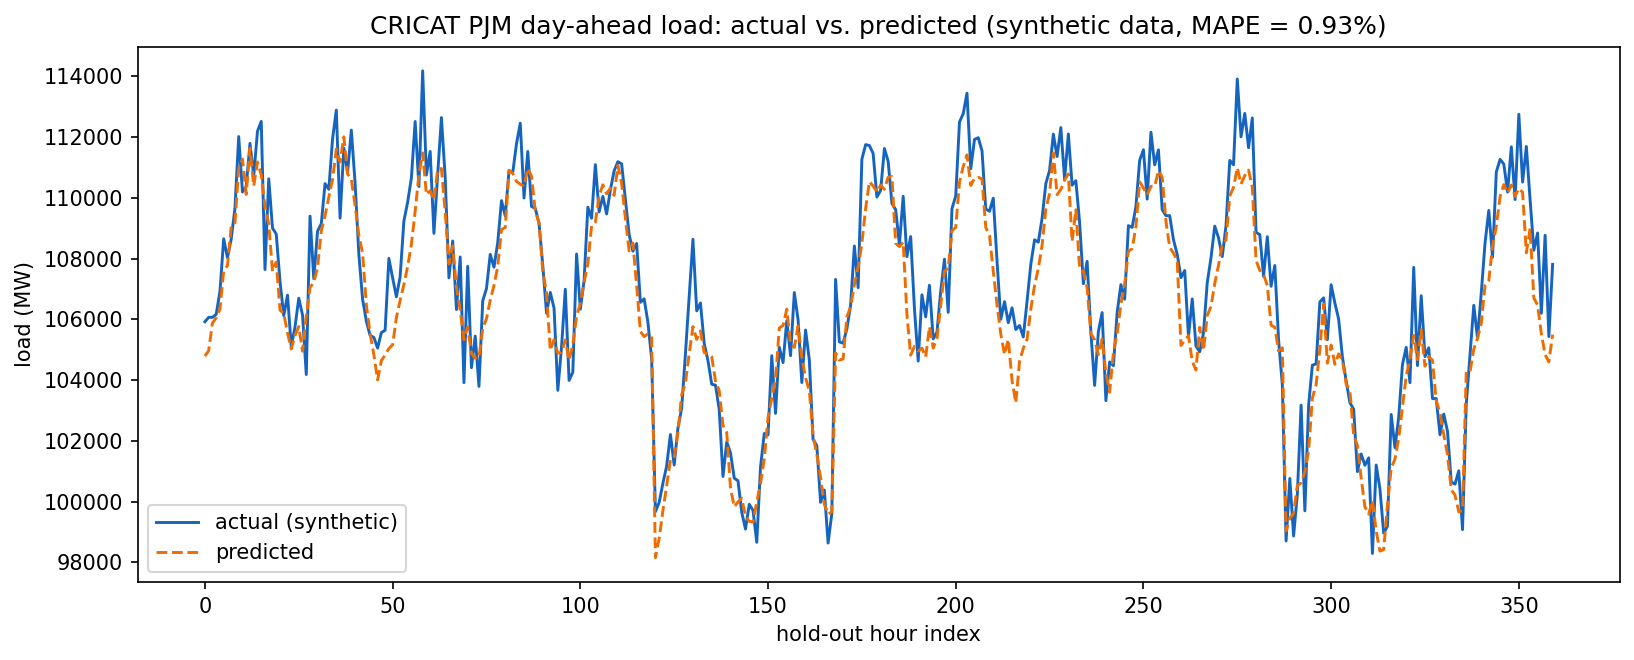

actual-vs-predicted chart rendered (synthetic PJM hold-out).


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4.5), dpi=150)
ax.plot(range(len(y_test)), y_test, label='actual (synthetic)', color='#1565c0', linewidth=1.4)
ax.plot(range(len(y_hat)), y_hat, label='predicted', color='#ef6c00', linewidth=1.4, linestyle='--')
ax.set_xlabel('hold-out hour index')
ax.set_ylabel('load (MW)')
ax.set_title(f'CRICAT PJM day-ahead load: actual vs. predicted '
             f'(synthetic data, MAPE = {fc.test_mape:.2f}%)')
ax.legend()
plt.tight_layout()
plt.show()
print('actual-vs-predicted chart rendered (synthetic PJM hold-out).')

## 5. Emit a day-ahead `load_forecast_record` and validate it

`predict_day_ahead` produces schema-conformant records with prediction intervals derived from the held-out residual quantiles.

In [6]:
import json

from cricat.load_forecasting.forecaster import predict_day_ahead
from shared.utilities.schema_loader import validate_record

records = predict_day_ahead('PJM', forecaster=fc, horizon_hours=24)
print('emitted load_forecast_record documents:', len(records))
print(json.dumps(records[0], indent=2))

all_ok = all(validate_record(r, 'load_forecast_record') for r in records)
print('\nall', len(records), 'records valid against load_forecast_record:', all_ok)

emitted load_forecast_record documents: 24
{
  "forecast_id": "CRICAT-FC-PJM-0000",
  "iso_region": "PJM",
  "forecast_issued_at_utc": "2026-03-12T00:00:00Z",
  "target_window_start_utc": "2026-03-13T00:00:00Z",
  "target_window_end_utc": "2026-03-13T01:00:00Z",
  "predicted_load_mw": 104302.4,
  "prediction_interval_low_mw": 103598.0,
  "prediction_interval_high_mw": 106320.0,
  "model_id": "cricat-gbr-dayahead-v0.1",
  "input_data_sources": [
    "synthetic_load_history",
    "synthetic_weather",
    "calendar_features"
  ]
}

all 24 records valid against load_forecast_record: True


---

**Recap.** The forecaster trained and evaluated on a chronological hold-out of the synthetic PJM series, the recomputed MAPE matched the trainer's report, actual-vs-predicted was plotted, and emitted `load_forecast_record` documents validated against the registry. All inputs and outputs are synthetic illustrative data; no proprietary or employer content is used.